In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import Angle, SkyCoord, EarthLocation, AltAz
from astropy.time import Time
from astropy.table import Table
from gammapy.data import Observation, observatory_locations, EventList
from gammapy.datasets import MapDataset, MapDatasetEventSampler, FluxPointsDataset
from gammapy.estimators import ASmoothMapEstimator, TSMapEstimator, ExcessMapEstimator
from gammapy.estimators import FluxPointsEstimator
from gammapy.estimators.utils import resample_energy_edges
from gammapy.irf import load_irf_dict_from_file
from gammapy.makers import MapDatasetMaker, RingBackgroundMaker, SafeMaskMaker
from gammapy.datasets import MapDataset, MapDatasetOnOff
from gammapy.makers import MapDatasetMaker, WobbleRegionsFinder
from gammapy.maps import MapAxis, RegionNDMap, WcsGeom, Map, TimeMapAxis
from gammapy.modeling import Fit
from gammapy.modeling.models import (
    ConstantSpectralModel,
    FoVBackgroundModel,
    LightCurveTemplateTemporalModel,
    Models,
    PointSpatialModel,
    PowerLawSpectralModel,
    LogParabolaSpectralModel,
    SkyModel,
)
from gammapy.estimators import LightCurveEstimator
from regions import PointSkyRegion, CircleSkyRegion

from IPython.display import display
from gammapy.data import DataStore
from gammapy.datasets import (
    Datasets,
    FluxPointsDataset,
    SpectrumDataset,
    SpectrumDatasetOnOff,
)
from gammapy.estimators import FluxPointsEstimator
from gammapy.makers import (
    ReflectedRegionsBackgroundMaker,
    SafeMaskMaker,
    SpectrumDatasetMaker,
    FoVBackgroundMaker
)
from gammapy.maps import MapAxis, RegionGeom, WcsGeom
from gammapy.modeling import Fit
from gammapy.modeling.models import (
    ExpCutoffPowerLawSpectralModel,
    SkyModel,
    create_crab_spectral_model,
    PiecewiseNormSpectralModel,
    PowerLawNormSpectralModel,
    LogParabolaSpectralModel,
)

from gammapy.visualization import plot_spectrum_datasets_off_regions

import warnings

In [2]:
import yaml

def read_yaml(file_path):
    with open(file_path, "r") as f:
        return yaml.safe_load(f)

## Read the parfile

In [3]:
parfile = "./ASTRI_quicklook_analysis_parfile.yaml"
global_parameters = read_yaml(parfile)

## Make the output dir

In [4]:
output_dir = global_parameters['OUTPUT_RESULTS']['output_dir']
output_dir_notebook = global_parameters['OUTPUT_RESULTS']['lightcurve_analysis_output_dir']
Path(output_dir).mkdir(parents=True, exist_ok=True)
Path(output_dir).joinpath(output_dir_notebook).mkdir(parents=True, exist_ok=True)

## Load the ASTRI data

In [5]:
import glob, os, pathlib, itertools

target_name = global_parameters["TARGET"]["target_name"]

input_filenames = []
for folder in global_parameters['INPUT_DATA']['input_EVT3']:
    input_filenames.append(glob.glob(os.path.join(folder, f'*{target_name}*_0201_*.fits.gz')))
input_filenames = tuple(itertools.chain.from_iterable(input_filenames))

irf_filenames = []
for folder in global_parameters['INPUT_DATA']['input_IRF3']:
    irf_filenames.append(glob.glob(os.path.join(folder, f'*{target_name}*_0502_*.fits.gz')))
irf_filenames = tuple(itertools.chain.from_iterable(irf_filenames))

print(f"The number of runs is {len(input_filenames)}; the number of IRF is {len(irf_filenames)}.")
if len(input_filenames) != len(irf_filenames):
    warnings.warn("The number of runs is not compatible with the available IRFs! PLEASE CHECK!")
else:
    print("Run and abailable IRFs are compatible!")

datastore = DataStore.from_events_files(np.sort(input_filenames), irfs_paths=np.sort(irf_filenames))
datastore.hdu_table.write("hdu-index.fits.gz", overwrite=True)
datastore.obs_table.write("obs-index.fits.gz", overwrite=True)

The number of runs is 49; the number of IRF is 49.
Run and abailable IRFs are compatible!


In [6]:
telescope_name = global_parameters["DATA_ORIGIN"]["telescope"]
target_name = global_parameters["TARGET"]["target_name"]
obs_date = datastore.obs_table[0]["EVENTS_FILENAME"].split("/")[-1][0:8]

In [7]:
import json

with open(f'{output_dir}/{output_dir_notebook}/lightcurve_analysis_parfile_summary_{obs_date}_{telescope_name}_{target_name}.txt', 'w') as file:
    file.write(json.dumps(global_parameters))

## Create AZ/ZD columns in the datastore for each run

In [8]:
ev_header = Table.read(datastore.obs_table["EVENTS_FILENAME"][0], hdu=1)
meta = ev_header.meta
loc = EarthLocation(
            lat=global_parameters['DATA_ORIGIN']['latitude'],
            lon=global_parameters['DATA_ORIGIN']['longitude'],
            # height = (row["TELZ"] + OBSLEV)*u.m
        )

mjdtime = ( ((datastore.obs_table["TSTART"] + datastore.obs_table["TSTOP"])/2).to("d") 
           + (datastore.obs_table["MJDREFI"] + datastore.obs_table["MJDREFF"]) * u.d )
observing_time = Time(mjdtime, format="mjd", scale="tt")  

altazframe = AltAz(location=loc, obstime=observing_time)
datastore.obs_table["DATE-OBS"] = observing_time.isot 
coord = SkyCoord(datastore.obs_table["RA_PNT"], datastore.obs_table["DEC_PNT"], unit="deg", frame="icrs")
coord_altaz = coord.transform_to(altazframe)

datastore.obs_table["AZ_PNT"] = coord_altaz.az.deg * u.deg
datastore.obs_table["ZD_PNT"] = coord_altaz.zen.deg * u.deg

## Select runs according to selection criteria

In [9]:
target_position = SkyCoord(ra=global_parameters['TARGET']['coord1'], 
                           dec=global_parameters['TARGET']['coord2'], 
                           unit="deg", 
                           frame=global_parameters['TARGET']['frame'])

selection_offset = dict(type='sky_circle',
                lon=target_position.ra.deg,
                lat=target_position.dec.deg,
                frame="icrs",
                radius=Angle(global_parameters['RUN_SELECTION']['offset_max'], 'deg')
                )

value_range_zen = Angle([global_parameters['RUN_SELECTION']['zenith_min'], 
                         global_parameters['RUN_SELECTION']['zenith_max']], 'deg')
selection_zen = dict(type='par_box', variable='ZD_PNT', value_range=value_range_zen)

value_range_az = Angle([global_parameters['RUN_SELECTION']['azimuth_min'], 
                     global_parameters['RUN_SELECTION']['azimuth_max']], 'deg')
selection_az = dict(type='par_box', variable='AZ_PNT', value_range=value_range_az)

value_range_time = np.array([global_parameters['RUN_SELECTION']['tstart'],
                             global_parameters['RUN_SELECTION']['tstop']], float) * u.s
selection_time = dict(type='par_box', variable='TSTART', value_range=value_range_time)

select_obs = datastore.obs_table.select_observations([selection_offset, selection_zen, selection_az, selection_time])
selected_obsid = select_obs["OBS_ID"]

In [10]:
print(f"The mean exposure of the runs is {np.mean(select_obs['LIVETIME']) * u.s} \n")
print(f"The total exposure time is {(np.sum(select_obs['LIVETIME']) * u.s).to('hr')} \n")
print(f"The total runs are {len(select_obs['OBS_ID'])}. These are the selected ObsID: \n {select_obs['OBS_ID']} \n")

The mean exposure of the runs is 1933.6122448979593 s 

The total exposure time is 26.31861111111111 h 

The total runs are 49. These are the selected ObsID: 
   OBS_ID  
----------
 433001063
 486001135
 487001136
 488001137
 507001172
 553001221
 554001222
 612001388
 619001403
 620001404
       ...
 985001976
 998001994
 999001995
1007002010
1008002011
1015002025
1041002054
1042002055
1056002075
1064002087
Length = 49 rows 



In [11]:
file_path = Path(f"{output_dir}/{output_dir_notebook}/lightcurve_analysis_summary_table_{obs_date}_{telescope_name}_{target_name}.txt")
with file_path.open('w') as file:
    file.write(f"The mean exposure of the runs is {np.mean(select_obs['LIVETIME']) * u.s} \n\n" +
               f"The total exposure time is {(np.sum(select_obs['LIVETIME']) * u.s).to('hr')} \n\n" +
               f"The total runs are {len(select_obs['OBS_ID'])}. These are the selected ObsID: \n {select_obs['OBS_ID']}"
              )

## Load the observations

In [12]:
observations = datastore.get_observations(obs_id=selected_obsid)

In [13]:
a = observations[0]
a.gti

## 1D Spectral analysis: reflected regions

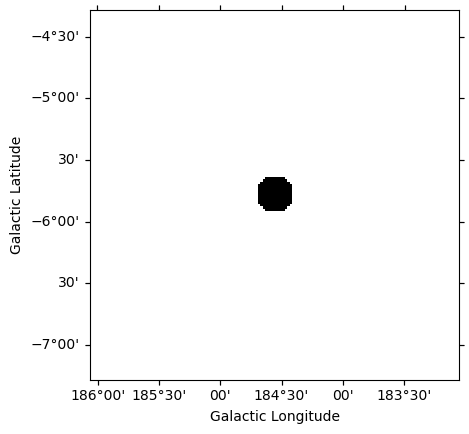

In [14]:
width = global_parameters['DATASET_SETTINGS']['width']
binsz = global_parameters['DATASET_SETTINGS']['binsz']
radius= np.sqrt(global_parameters['DATASET_SETTINGS']['on_radius'])

on_region_radius = Angle(radius * u.deg)
on_region = CircleSkyRegion(center=target_position, radius=on_region_radius)

npix = int(width/binsz)

exclusion_region = [CircleSkyRegion(
    center=target_position,
    radius=radius * u.deg,
    )]

for i, src in enumerate(global_parameters['EXCLUSION_REGIONS']['source']):
    src_position = SkyCoord(ra=global_parameters['EXCLUSION_REGIONS']['src_coord1'][i], 
                            dec=global_parameters['EXCLUSION_REGIONS']['src_coord2'][i], 
                            unit="deg", 
                            frame=global_parameters['EXCLUSION_REGIONS']['frame'][i])
    
    src_exclusion_region = CircleSkyRegion(
                                    center=src_position,
                                    radius=global_parameters['EXCLUSION_REGIONS']['src_radius'][i] * u.deg,
                                    )
    exclusion_region.append(src_exclusion_region)

geom_excl = WcsGeom.create(
    npix=(npix, npix), binsz=binsz, skydir=target_position.galactic, proj="TAN", frame="galactic"
)

exclusion_mask = ~geom_excl.region_mask(exclusion_region)
exclusion_mask.plot()

plt.savefig(f"{output_dir}/{output_dir_notebook}/Exclusion_mask_{obs_date}_{telescope_name}_{target_name}.pdf", bbox_inches='tight')

In [15]:
e_min, e_max = (global_parameters['DATASET_SETTINGS']['energy_reco_min'] * u.TeV, 
                global_parameters['DATASET_SETTINGS']['energy_reco_max'] * u.TeV) 

energy_axis = MapAxis.from_energy_bounds(
                    e_min, e_max, 
                    nbin=global_parameters['DATASET_SETTINGS']['nbin_reco'], 
                    per_decade=False, unit="TeV", name="energy") 

# Reduced IRFs are defined in true energy (i.e. not measured energy).
energy_axis_true = MapAxis.from_energy_bounds(
                    global_parameters['DATASET_SETTINGS']['energy_true_min'], 
                    global_parameters['DATASET_SETTINGS']['energy_true_max'], 
                    nbin=global_parameters['DATASET_SETTINGS']['nbin_true'], 
                    per_decade=False, unit="TeV", name="energy_true" 
                    )

# geometry defining the ON region and SpectrumDataset based on it
geom = RegionGeom.create(region=on_region, axes=[energy_axis])

dataset_empty = SpectrumDataset.create(geom=geom, energy_axis_true=energy_axis_true)

dataset_maker = SpectrumDatasetMaker(
    containment_correction=True, selection=["counts", "exposure", "edisp"]
)

if global_parameters['DATASET_SETTINGS']['full_reflected_regions'] == False:
    # tell the background maker to use the WobbleRegionsFinder, let us use 3 off by default
    region_finder = WobbleRegionsFinder(n_off_regions=3)
    maker_fov = ReflectedRegionsBackgroundMaker(region_finder=region_finder, exclusion_mask=exclusion_mask)
else:
    maker_fov = ReflectedRegionsBackgroundMaker(exclusion_mask=exclusion_mask)

offset_max = global_parameters['SAFEMASK_DATSET']['offset_max'] * u.deg
safe_mask_masker = SafeMaskMaker(
#    methods=["offset-max", "aeff-max"], aeff_percent=5, offset_max=offset_max
    methods=["aeff-default","offset-max"], offset_max=offset_max
 )

In [16]:
datasets = Datasets()

# create a counts map for visualisation later...
#counts = Map.create(skydir=target_position, width=width)
counts= Map.from_geom(geom_excl)

for observation in observations:
    dataset = dataset_maker.run(
        dataset_empty.copy(name=str(observation.obs_id)), observation
    )
    counts.fill_events(observation.events)
    dataset_on_off = maker_fov.run(dataset, observation)
    dataset_on_off = safe_mask_masker.run(dataset_on_off, observation)
    datasets.append(dataset_on_off)

No default upper safe energy threshold defined for obs 433001063
No default lower safe energy threshold defined for obs 433001063
No default upper safe energy threshold defined for obs 486001135
No default lower safe energy threshold defined for obs 486001135
No default upper safe energy threshold defined for obs 487001136
No default lower safe energy threshold defined for obs 487001136
No default upper safe energy threshold defined for obs 488001137
No default lower safe energy threshold defined for obs 488001137
No default upper safe energy threshold defined for obs 507001172
No default lower safe energy threshold defined for obs 507001172
No default upper safe energy threshold defined for obs 553001221
No default lower safe energy threshold defined for obs 553001221
No default upper safe energy threshold defined for obs 554001222
No default lower safe energy threshold defined for obs 554001222
No default upper safe energy threshold defined for obs 612001388
No default lower safe ene

/opt/anaconda3/envs/gammapy-2.0.1/lib/python3.12/site-packages/regions/shapes/circle.py:160: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  return Circle(xy=xy, radius=radius, **mpl_kwargs)


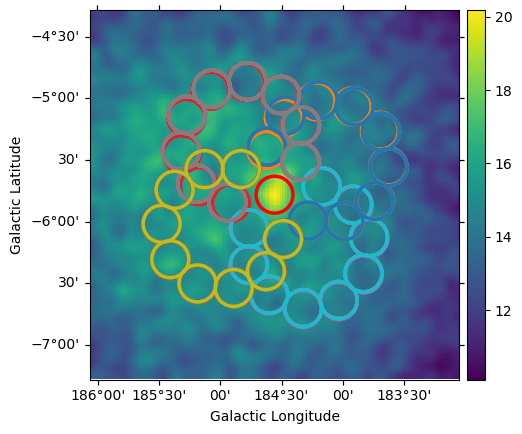

In [17]:
#plot
ax = counts.smooth(0.05 * u.deg).plot(stretch="linear", cmap="viridis", add_cbar=True)
geom.plot_region(ax=ax, kwargs_point={"color": "k", "marker": "*"}, color="r", linewidth=2.5)
plot_spectrum_datasets_off_regions(ax=ax, datasets=datasets, linewidth=2.5)

plt.savefig(f"{output_dir}/{output_dir_notebook}/lightcurve_analysis_counts_map_reflected_{obs_date}_{telescope_name}_{target_name}.pdf", bbox_inches='tight')

In [18]:
# Individual
info_table=datasets.info_table()
info_table

name,counts,excess,sqrt_ts,background,npred,npred_background,npred_signal,exposure_min,exposure_max,livetime,ontime,counts_rate,background_rate,excess_rate,n_bins,n_fit_bins,stat_type,stat_sum,counts_off,acceptance,acceptance_off,alpha
,,,,,,,,m2 s,m2 s,s,s,1 / s,1 / s,1 / s,,,,,,,,
str10,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,str5,float64,int64,float64,float64,float64
433001063,57,11.777777777777786,1.5896771257831814,45.222222222222214,46.4,46.4,nan,30734.426751028852,240496173.6092202,1981.9984143078318,1981.9984143078318,0.02875885247360602,0.02281647749855292,0.0059423749750531,16,16,wstat,7.941580340836493,407,16.0,144.00000000000003,0.11111111111111109
486001135,35,1.4444444444444429,0.23472474965080614,33.55555555555556,33.7,33.7,nan,22143.750706347277,173274333.6120534,1428.0038193762323,1428.0038193762323,0.024509738367008278,0.023498225355036508,0.0010115130119717692,16,16,wstat,17.606430246152936,302,16.0,144.0,0.11111111111111112
487001136,59,8.222222222222229,1.064146590351208,50.77777777777777,51.599999999999994,51.599999999999994,nan,28145.03812824711,220234267.9354659,1815.0141986608494,1815.0141986608494,0.032506632754460696,0.02797651820864131,0.0045301145458193845,16,16,wstat,9.255193925090548,457,16.0,144.00000000000003,0.11111111111111109
488001137,56,12.777777777777779,1.7544284444386424,43.22222222222222,44.5,44.5,nan,28222.5128814999,220840506.075502,1820.0103822350509,1820.0103822350509,0.030769055246393482,0.023748338275490208,0.007020716970903275,16,16,wstat,17.229861591361825,389,16.0,144.0,0.1111111111111111
507001172,65,22.000000000000007,2.9338486892698414,42.99999999999999,45.2,45.2,nan,28036.439309318783,219384484.7063102,1808.0108896791917,1808.0108896791917,0.03595111089819454,0.023783042594190233,0.01216806830400431,16,16,wstat,27.830102491662842,387,16.0,144.00000000000003,0.11111111111111109
553001221,64,14.0,1.7915630788055676,50.0,51.4,51.4,nan,28486.21223741352,222903947.3947164,1837.0157980024783,1837.0157980024783,0.03483911247229985,0.027218056618984257,0.007621055853315592,16,16,wstat,16.038482248441703,450,16.0,144.0,0.1111111111111111
554001222,60,10.555555555555564,1.3727764279898151,49.444444444444436,50.5,50.5,nan,28129.552453820572,220113092.89369562,1814.0155601501497,1814.0155601501497,0.033075791254532395,0.027256902052346134,0.005818889202186259,16,16,wstat,14.082602838375331,445,16.0,144.00000000000003,0.11111111111111109
612001388,35,14.555555555555557,2.740607910008604,20.444444444444443,21.9,21.9,nan,13940.734123649161,109085919.87741818,899.0085662305312,899.0085662305312,0.03893177586366292,0.02274110082194913,0.016190675041713787,16,16,wstat,20.338520907904098,184,16.0,144.0,0.1111111111111111


In [19]:
# Cumulative
info_table= datasets.info_table(cumulative=True)
info_table

name,counts,excess,sqrt_ts,background,npred,npred_background,npred_signal,exposure_min,exposure_max,livetime,ontime,counts_rate,background_rate,excess_rate,n_bins,n_fit_bins,stat_type,stat_sum,counts_off,acceptance,acceptance_off,alpha
,,,,,,,,m2 s,m2 s,s,s,1 / s,1 / s,1 / s,,,,,,,,
str7,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,str5,float64,int64,float64,float64,float64
stacked,57,11.777778625488281,1.5896770761023833,45.22222137451172,46.40000031113625,46.40000031113625,nan,30734.42578125,240496176.0,1981.9984143078318,1981.9984143078318,0.02875885247360602,0.02281647707084799,0.0059423754027580315,16,16,wstat,7.941580182883847,407,16.0,144.0,0.1111111119389534
stacked,92,13.222221374511719,1.3725398837362772,78.77777862548828,80.09999953530728,80.09999953530728,nan,52878.17578125,413770496.0,3410.002233684064,3410.002233684069,0.02697945446815909,0.023101972734011714,0.0038774817341473786,16,16,wstat,11.38150037932012,709,32.0,288.0,0.1111111119389534
stacked,151,21.444442749023438,1.7365057650660773,129.55555725097656,131.70000107623636,131.70000107623636,nan,81023.21875,634004736.0,5225.0164323449135,5225.016432344923,0.02889943064394026,0.024795243982196218,0.0041041866617440425,16,16,wstat,11.014047148355242,1166,48.0,432.0,0.1111111119389534
stacked,207,34.22221374511719,2.3868670831883585,172.7777862548828,176.20000118151307,176.20000118151307,nan,109245.734375,854845248.0,7045.026814579965,7045.026814579978,0.02938242897409634,0.024524787598723157,0.004857641375373185,16,16,wstat,16.505923679503525,1555,64.0,575.9999389648438,0.111111119389534
stacked,272,56.22222900390625,3.4739093375936343,215.77777099609375,221.40000168979165,221.40000168979165,nan,137282.171875,1074229760.0,8853.037704259157,8853.03770425917,0.030723917494346827,0.02437330306322812,0.006350614431118709,16,16,wstat,26.984117011665603,1942,80.0,720.0000610351562,0.1111111044883728
stacked,336,70.22222900390625,3.9073176202972237,265.77777099609375,272.8000037906319,272.8000037906319,nan,165768.390625,1297133696.0,10690.053502261635,10690.053502261653,0.03143108684431882,0.02486215536151102,0.006568931482807801,16,16,wstat,23.815583778724033,2392,96.0,864.0,0.1111111119389534
stacked,396,80.77777099609375,4.132300818768606,315.22222900390625,323.29999913834024,323.29999913834024,nan,193897.9375,1517246720.0,12504.069062411785,12504.069062411803,0.03166969072415052,0.025209571974573387,0.006460118749577134,16,16,wstat,26.703580082299837,2837,112.0,1008.0,0.1111111119389534
stacked,431,95.33331298828125,4.705523581521848,335.66668701171875,345.2000008965282,345.2000008965282,nan,207838.671875,1626332672.0,13403.077628642317,13403.077628642335,0.03215679353217763,0.0250440008117539,0.007112792720423732,16,16,wstat,30.760637890659794,3021,128.0,1151.9998779296875,0.111111119389534


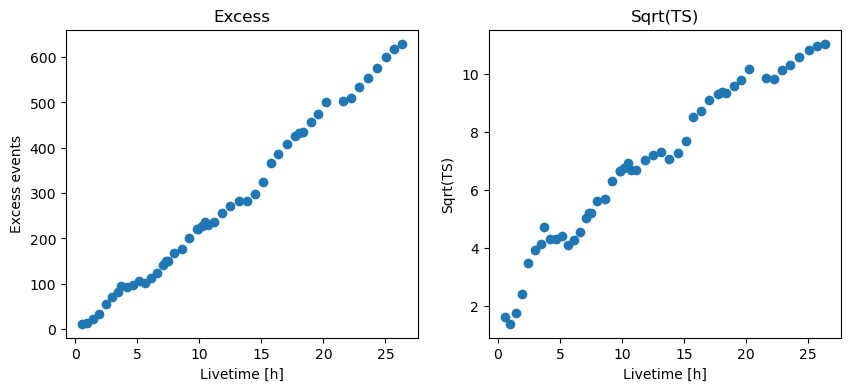

In [20]:
fig, (ax_excess, ax_sqrt_ts) = plt.subplots(figsize=(10, 4), ncols=2, nrows=1)
ax_excess.plot(
    info_table["livetime"].to("h"),
    info_table["excess"],
    marker="o",
    ls="none",
)

ax_excess.set_title("Excess")
ax_excess.set_xlabel("Livetime [h]")
ax_excess.set_ylabel("Excess events")

ax_sqrt_ts.plot(
    info_table["livetime"].to("h"),
    info_table["sqrt_ts"],
    marker="o",
    ls="none",
)

ax_sqrt_ts.set_title("Sqrt(TS)")
ax_sqrt_ts.set_xlabel("Livetime [h]")
ax_sqrt_ts.set_ylabel("Sqrt(TS)")

plt.savefig(f"{output_dir}/{output_dir_notebook}/lightcurve_analysis_excess_significance_{obs_date}_{telescope_name}_{target_name}.pdf", bbox_inches='tight')

## Run a stacked spectral analysis

In [21]:
dataset_stacked = Datasets(datasets).stack_reduce()

In [22]:
if global_parameters['SPECTRAL_MODEL']['model'] == "powerlaw":
    spectral_model = PowerLawSpectralModel(index=global_parameters['SPECTRAL_MODEL']['index'], 
                                           amplitude=global_parameters['SPECTRAL_MODEL']['amplitude'], 
                                           reference=global_parameters['SPECTRAL_MODEL']['reference'])
if global_parameters['SPECTRAL_MODEL']['model'] == "logparabola":
    spectral_model = LogParabolaSpectralModel(alpha=global_parameters['SPECTRAL_MODEL']['alpha'], 
                                              beta=global_parameters['SPECTRAL_MODEL']['beta'], 
                                              amplitude=global_parameters['SPECTRAL_MODEL']['amplitude'], 
                                              reference=global_parameters['SPECTRAL_MODEL']['reference'])
    #spectral_model.parameters["alpha"].frozen = True
    spectral_model.parameters["beta"].frozen = True

model = SkyModel(spectral_model=spectral_model, name=global_parameters['TARGET']['target_name'])
dataset_stacked.models = model
dataset_stacked.models[0].spectral_model.amplitude.min = 0

dataset_stacked.mask_fit = dataset_stacked.counts.geom.energy_mask(
    energy_min=global_parameters['SPECTRAL_FIT']['energy_min'] * u.TeV, energy_max=global_parameters['SPECTRAL_FIT']['energy_max']*u.TeV
)

In [23]:
fit = Fit()
result_stacked = fit.run(dataset_stacked)

print(result_stacked)

# we make a copy here to compare it later
best_fit_model = datasets.models.copy()

OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	message    : Optimization terminated successfully.
	nfev       : 46
	total stat : 12.38

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.



In [24]:
dataset_stacked.models.parameters.to_table()

type,name,value,unit,error,min,max,frozen,link,prior
str1,str9,float64,str14,float64,float64,float64,bool,str1,str1
,index,2.6432e+00,,1.396e-01,nan,nan,False,,
,amplitude,4.4194e-12,TeV-1 s-1 cm-2,4.256e-13,0.000e+00,nan,False,,
,reference,2.0000e+00,TeV,0.000e+00,nan,nan,True,,


In [25]:
# write best fit
dataset_stacked.models.parameters.to_table().write(f"{output_dir}/{output_dir_notebook}/lightcurve_analysis_best_fit_model_{obs_date}_{telescope_name}_{target_name}.txt", format="ascii", overwrite=True)

In [26]:
dataset_stacked.models[0].spectral_model

## Make the lightcurve

In [27]:
if global_parameters['SPECTRAL_MODEL_TO_COMPARE']['model'] == "powerlaw":
    model_crab = PowerLawSpectralModel(index=global_parameters['SPECTRAL_MODEL_TO_COMPARE']['index'], 
                                           amplitude=global_parameters['SPECTRAL_MODEL_TO_COMPARE']['amplitude'], 
                                           reference=global_parameters['SPECTRAL_MODEL_TO_COMPARE']['reference'])
    name = global_parameters['SPECTRAL_MODEL_TO_COMPARE']['name']
if global_parameters['SPECTRAL_MODEL_TO_COMPARE']['model'] == "logparabola":
    model_crab = LogParabolaSpectralModel(alpha=global_parameters['SPECTRAL_MODEL_TO_COMPARE']['alpha'], 
                                              beta=global_parameters['SPECTRAL_MODEL_TO_COMPARE']['beta'], 
                                              amplitude=global_parameters['SPECTRAL_MODEL_TO_COMPARE']['amplitude'], 
                                              reference=global_parameters['SPECTRAL_MODEL_TO_COMPARE']['reference'])
    name = global_parameters['SPECTRAL_MODEL_TO_COMPARE']['name']

In [28]:
emin, emax = global_parameters["LIGHTCURVE_ANALYSIS"]['emin'] * u.TeV, global_parameters["LIGHTCURVE_ANALYSIS"]['emax'] * u.TeV

#model_crab = LogParabolaSpectralModel.from_log10(alpha=2.47, beta=0.24, amplitude="3.23e-11 cm-2 s-1 TeV-1", reference="1 TeV")
flux_crab = model_crab.energy_flux_error(emin,emax).to("erg cm-2 s-1")
flux_int_crab = model_crab.integral_error(emin,emax)

# #sky_model = SkyModel(spectral_model=spectral_model, name="crab")
sky_model = SkyModel(spectral_model=dataset_stacked.models[0].spectral_model, name=global_parameters["TARGET"]['target_name'])

In [29]:
models = Models([sky_model])
datasets.models = models

In [30]:
if global_parameters["LIGHTCURVE_ANALYSIS"]['time_usr_defined'] is True:
    if global_parameters["LIGHTCURVE_ANALYSIS"]['time_range'] is not None:
        time_intervals = []
        for i in np.arange(len(global_parameters["LIGHTCURVE_ANALYSIS"]['time_range'])):
            time_intervals.append(Time(global_parameters["LIGHTCURVE_ANALYSIS"]['time_range'][i], 
                                       format=global_parameters["LIGHTCURVE_ANALYSIS"]['format'], 
                                       scale=global_parameters["LIGHTCURVE_ANALYSIS"]['scale']))

    elif global_parameters["LIGHTCURVE_ANALYSIS"]['bin_time'] is not None and global_parameters["LIGHTCURVE_ANALYSIS"]['time_range'] is None:
        time_bin = u.Quantity(global_parameters["LIGHTCURVE_ANALYSIS"]['bin_time'])
        time_start = Time(str((datasets[0].gti.time_start - 5*u.s).isot[0]), format = "isot", scale = datasets[0].gti.time_start.scale)
        time_stop = time_start

        time_intervals = []
        while time_stop.mjd < datasets[-1].gti.time_stop.mjd:
            time_stop = time_start + time_bin
            time_intervals.append(Time([str(time_start), str(time_stop)], 
                                  format="isot", 
                                  scale=datasets[0].gti.time_start.scale))
            time_start = time_stop

    else:
        raise ValueError("For user defined time intervals, one amongst either `time_usr_defined` or `bin_time` keywords has to be defined!")
else:
    time_intervals = [Time([str((datasets[0].gti.time_start - 5*u.s).isot[0]), str((datasets[-1].gti.time_stop + 5*u.s).isot[-1])], 
                     format = "isot",
                     scale = datasets[0].gti.time_start.scale
                    )]

In [31]:
lc_maker_all = LightCurveEstimator(
    energy_edges=[emin,emax],
    time_intervals=time_intervals,
    source=global_parameters["TARGET"]['target_name'],
    reoptimize=False,
    selection_optional="all",
    n_sigma=global_parameters["LIGHTCURVE_ANALYSIS"]['n_sigma'], 
    n_sigma_ul=global_parameters["LIGHTCURVE_ANALYSIS"]['n_sigma_ul'], 
    n_jobs=7
)

lc_maker_all.norm.scan_max = 3

time_lc = lc_maker_all.run(datasets)
time_lc.sqrt_ts_threshold_ul = global_parameters['LIGHTCURVE_ANALYSIS']['sqrt_ts_threshold_ul'] # in units of sqrt(TS)

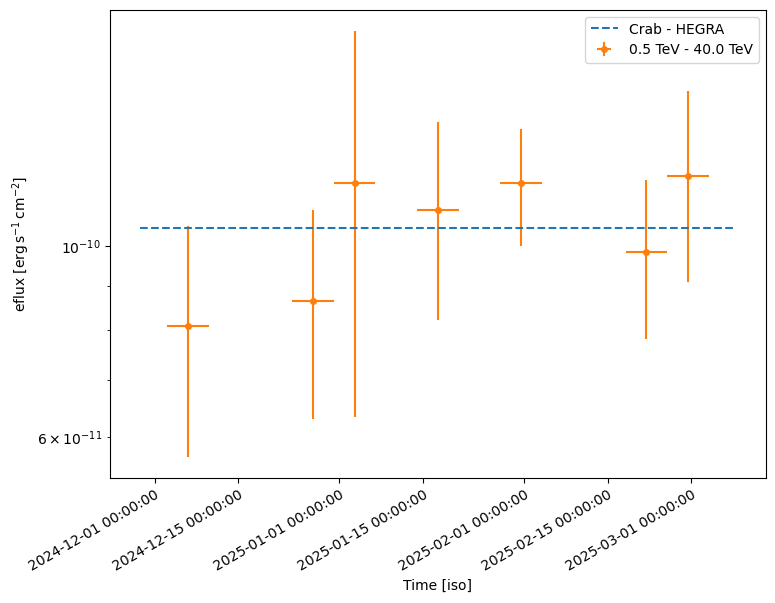

In [32]:
fig, ax = plt.subplots(
    figsize=(8, 6),
    gridspec_kw={"left": 0.16, "bottom": 0.2, "top": 0.98, "right": 0.98},
)

sed_type = global_parameters['LIGHTCURVE_ANALYSIS']['lc_type']

b = time_lc.plot(ax=ax, sed_type=sed_type, color="tab:orange", label = f"{emin} - {emax}", axis_name="time")

#ax.set_yscale("linear")
ax.set_yscale("log")

if sed_type == "eflux":
    ax.plot(ax.xaxis.get_view_interval(), 
            np.ones_like(ax.xaxis.get_view_interval()) * flux_crab[0], label = name, ls="dashed")

if sed_type == "flux":
    ax.plot(ax.xaxis.get_view_interval(), 
            np.ones_like(ax.xaxis.get_view_interval()) * flux_int_crab[0], label = name, ls="dashed")

#time_lc.plot_ts_profiles(ax=ax, sed_type=sed_type)
plt.legend()
plt.savefig(f"{output_dir}/{output_dir_notebook}/lightcurve_{global_parameters["LIGHTCURVE_ANALYSIS"]['emin']}-{global_parameters["LIGHTCURVE_ANALYSIS"]['emax']}TeV_{obs_date}_{telescope_name}_{target_name}.pdf", bbox_inches='tight')
plt.savefig(f"{output_dir}/{output_dir_notebook}/lightcurve_{global_parameters["LIGHTCURVE_ANALYSIS"]['emin']}-{global_parameters["LIGHTCURVE_ANALYSIS"]['emax']}TeV_{obs_date}_{telescope_name}_{target_name}.png", bbox_inches='tight')

In [33]:
time_lc.to_table()

time_min,time_max,e_ref,e_min,e_max,ref_dnde,ref_flux,ref_eflux,norm,norm_err,norm_errn,norm_errp,norm_ul,norm_sensitivity,ts,sqrt_ts,npred,npred_excess,stat,stat_null,stat_scan,is_ul,counts,success,norm_scan
,,TeV,TeV,TeV,1 / (TeV s cm2),1 / (s cm2),erg / (s cm2),,,,,,,,,,,,,,,,,
float64,float64,float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],"float64[1,49]","float64[1,49]",float64[1],float64[1],"float64[1,11]",bool[1],"float64[1,49]",bool[1],"float64[1,11]"
60647.024944375,60654.024944375,5.0118706877850085,0.5011867711748081,50.11873663823703,3.897653277294874e-13,5.225055194663641e-11,1.0169712974617476e-10,0.7950430089833327,0.23844623923161748,0.23461262964983504,0.24230201188648756,1.545305413681128,1.155614550432009,12.447645807684992,3.52812213616323,52.45251735809299 .. nan,10.317858695983887 .. nan,70.66985187177508,83.11749767946007,77.43542730166784 .. 136.73421241235945,False,53.0 .. nan,True,0.2 .. 3.0000000000000004
60668.024944375,60675.024944375,5.0118706877850085,0.5011867711748081,50.11873663823703,3.897653277294874e-13,5.225055194663641e-11,1.0169712974617476e-10,0.8490986402135071,0.23222066579070957,0.2287941191482612,0.23568371414391776,1.5772394528497657,1.1001159168002195,14.992471361108556,3.872011281118452,nan .. nan,nan .. nan,115.45302271240965,130.4454940735182,123.96989699843553 .. 183.3732263305194,False,nan .. nan,True,0.2 .. 3.0000000000000004
60675.024944375,60682.024944375,5.0118706877850085,0.5011867711748081,50.11873663823703,3.897653277294874e-13,5.225055194663641e-11,1.0169712974617476e-10,1.1645656200410799,0.5619061978399372,0.540862636674984,0.5834808917837873,3.0484484238126477,2.7782276432146147,5.113373515217386,2.261276965614205,nan .. nan,nan .. nan,19.85921362579187,24.972587141009257,23.255010125738625 .. 28.445301742546945,False,nan .. nan,True,0.2 .. 3.0000000000000004
60689.024944375,60696.024944375,5.0118706877850085,0.5011867711748081,50.11873663823703,3.897653277294874e-13,5.225055194663641e-11,1.0169712974617476e-10,1.0835022145843565,0.2806100713214716,0.2754547187479369,0.2860178251346768,1.9757033186534865,1.3008553074202243,17.487350535312963,4.1817879591525156,nan .. nan,nan .. nan,43.96008622075639,61.44743675606935,55.240362046541286 .. 81.07089601189915,False,nan .. nan,True,0.2 .. 3.0000000000000004
60703.024944375,60710.024944375,5.0118706877850085,0.5011867711748081,50.11873663823703,3.897653277294874e-13,5.225055194663641e-11,1.0169712974617476e-10,1.1636407353000597,0.18071965707373674,0.1789065672772825,0.1825573137551615,1.7225869781286427,0.7979361619690105,47.66574518849707,6.9040383246689085,nan .. nan,nan .. nan,124.43268125074628,172.09842643924335,156.30615758210192 .. 210.18140808917784,False,nan .. nan,True,0.2 .. 3.0000000000000004
60724.024944375,60731.024944375,5.0118706877850085,0.5011867711748081,50.11873663823703,3.897653277294874e-13,5.225055194663641e-11,1.0169712974617476e-10,0.9674959192380738,0.2032105081965533,0.2009466703961179,0.20550938318203527,1.598156698769002,0.9430014648234982,25.391794620679704,5.0390271502225215,nan .. nan,nan .. nan,102.62252214342898,128.01431676410868,118.21683892340212 .. 184.41700440790507,False,nan .. nan,True,0.2 .. 3.0000000000000004
60731.024944375,60738.024944375,5.0118706877850085,0.5011867711748081,50.11873663823703,3.897653277294874e-13,5.225055194663641e-11,1.0169712974617476e-10,1.1867833379271318,0.2979991072675179,0.29331254729357126,0.3027702222111077,2.1244231921503722,1.4235753837619847,18.161430187402217,4.261622952280295,nan .. 87.26208065273003,nan .. 18.292604446411133,39.965984328954434,58.12741451635665,52.22390495082438 .. 71.02021923900287,False,nan .. 81.0,True,0.2 .. 3.0000000000000004


## LC run-by-run

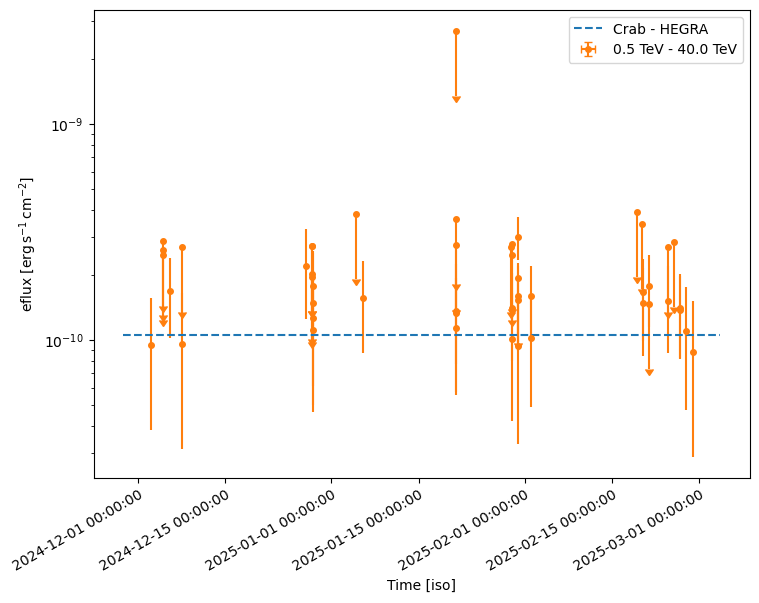

In [34]:
if global_parameters["LIGHTCURVE_ANALYSIS"]['run_by_run'] is True:
    time_intervals = []
    for dataset in datasets:
        inter = Time([str((dataset.gti.time_start - 5*u.s).isot[0]), str((dataset.gti.time_stop + 5*u.s).isot[0])], 
                         format = "isot",
                         scale = dataset.gti.time_start.scale)
        
        time_intervals.append(inter)
    
    lc_maker_run = LightCurveEstimator(
        energy_edges=[emin,emax],
        time_intervals=time_intervals,
        source=global_parameters["TARGET"]['target_name'],
        reoptimize=False,
        selection_optional="all",
        n_sigma=global_parameters["LIGHTCURVE_ANALYSIS"]['n_sigma'], 
        n_sigma_ul=global_parameters["LIGHTCURVE_ANALYSIS"]['n_sigma_ul'], 
        n_jobs=7
    )
    
    lc_maker_run.norm.scan_max = 3
    
    run_lc = lc_maker_run.run(datasets)
    run_lc.sqrt_ts_threshold_ul = global_parameters['LIGHTCURVE_ANALYSIS']['sqrt_ts_threshold_ul'] # in units of sqrt(TS)
    
    fig, ax = plt.subplots(
        figsize=(8, 6),
        gridspec_kw={"left": 0.16, "bottom": 0.2, "top": 0.98, "right": 0.98},
    )
    
    sed_type = global_parameters['LIGHTCURVE_ANALYSIS']['lc_type']
    
    b = run_lc.plot(ax=ax, sed_type=sed_type, color="tab:orange", label = f"{emin} - {emax}", axis_name="time")
    
    #ax.set_yscale("linear")
    ax.set_yscale("log")
    
    if sed_type == "eflux":
        ax.plot(ax.xaxis.get_view_interval(), 
                np.ones_like(ax.xaxis.get_view_interval()) * flux_crab[0], label = name, ls="dashed")
    
    if sed_type == "flux":
        ax.plot(ax.xaxis.get_view_interval(), 
                np.ones_like(ax.xaxis.get_view_interval()) * flux_int_crab[0], label = name, ls="dashed")
    
    #run_lc.plot_ts_profiles(ax=ax, sed_type=sed_type)
    plt.legend()
    plt.savefig(f"{output_dir}/{output_dir_notebook}/lightcurve_run_by_run_{global_parameters["LIGHTCURVE_ANALYSIS"]['emin']}-{global_parameters["LIGHTCURVE_ANALYSIS"]['emax']}TeV_{obs_date}_{telescope_name}_{target_name}.pdf", bbox_inches='tight')
    plt.savefig(f"{output_dir}/{output_dir_notebook}/lightcurve_run_by_run_{global_parameters["LIGHTCURVE_ANALYSIS"]['emin']}-{global_parameters["LIGHTCURVE_ANALYSIS"]['emax']}TeV_{obs_date}_{telescope_name}_{target_name}.png", bbox_inches='tight')